# Advanced RAG - Hybrid Retrieval + RRF + Reranking (with RAGAS Evaluation)

**What this notebook shows**
1. **Naive RAG** (baseline) - PDF -> chunk -> embed -> FAISS -> LLM
2. **Advanced RAG** - Hybrid retrieval (FAISS + BM25) + RRF fusion + Cross-Encoder reranking
3. **RAGAS evaluation** - measure both pipelines on 4 quality metrics

**Stack:** Groq (Llama-3.1-8B + 3.3-70B) - LangChain - FAISS - BM25 - sentence-transformers - CrossEncoder - RAGAS

---

## Runs anywhere
Google Colab, Jupyter, JupyterLab, VS Code, Kaggle, local Python, Docker.

## Prerequisites

- **Python** 3.9 or newer
- **RAM** 4 GB+ (embeddings + FAISS + reranker)
- **Disk** ~500 MB (Hugging Face cache)
- **GROQ_API_KEY** - free at [console.groq.com/keys](https://console.groq.com/keys)

> Free Groq tier has a daily token limit (~100K TPD on 70B models). The RAGAS step is heaviest - on 429 rate-limit, wait ~15 min or switch the judge model to `llama-3.1-8b-instant`.

In [ ]:
# ── Install dependencies (works on Colab / Jupyter / VS Code / local) ──
# Note: On Google Colab you may see a harmless warning about google-colab
# requiring requests==2.32.4 — that's a notice, not a failure.
!pip install -q \
    groq gradio python-dotenv \
    langchain langchain-core langchain-community langchain-groq \
    langchain-text-splitters langchain-huggingface \
    sentence-transformers faiss-cpu rank_bm25 pymupdf \
    ragas datasets pandas matplotlib \
    "requests>=2.32.4,<2.33"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 280.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.9/543.9 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.2/178.2 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.7/360

In [ ]:
# Importing libraries
import gradio as gr
import os
import re
import numpy as np
from typing import List

# LangChain
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader, PyMuPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

from rank_bm25 import BM25Okapi
from sentence_transformers import CrossEncoder

# Groq
from groq import Groq


In [ ]:
# ══════════════════════════════════════════════════════════════════
# NAIVE RAG — Complete End-to-End
# Flow: PDF → Load → Chunk → Embed → Vector DB → Query → Retrieve → LLM → Answer
# ══════════════════════════════════════════════════════════════════
import os
from getpass import getpass

# ── Portable API key loader — works in Colab, Jupyter, VS Code, local Python ──
def load_groq_key():
    # 1. Already in environment? (CI/CD, Docker, exported in shell)
    if os.environ.get("GROQ_API_KEY"):
        return "environment"
    # 2. Google Colab secrets
    try:
        from google.colab import userdata
        os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
        return "colab-secrets"
    except (ImportError, ModuleNotFoundError):
        pass
    # 3. .env file (local dev with python-dotenv)
    try:
        from dotenv import load_dotenv
        if load_dotenv() and os.environ.get("GROQ_API_KEY"):
            return "dotenv"
    except ImportError:
        pass
    # 4. Interactive prompt (Jupyter / VS Code / terminal)
    os.environ["GROQ_API_KEY"] = getpass("Enter your GROQ_API_KEY: ").strip()
    return "prompt"

source = load_groq_key()
print(f"✅ GROQ_API_KEY loaded from: {source}")


In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 0 — Setup LLM client
# ─────────────────────────────────────────────────────────────────
client = Groq(api_key=os.environ["GROQ_API_KEY"])

def call_llm(prompt: str) -> str:
    res = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2,
    )
    return res.choices[0].message.content


In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 1 — READ PDF (auto-downloads if missing — works on any OS)
# ─────────────────────────────────────────────────────────────────
import os, urllib.request, tempfile

# Use /content if on Colab, else use OS-appropriate temp dir
if os.path.isdir("/content"):
    PDF_DIR = "/content"
else:
    PDF_DIR = os.path.join(tempfile.gettempdir(), "rag_demo")
    os.makedirs(PDF_DIR, exist_ok=True)

PDF_PATH = os.path.join(PDF_DIR, "Attention is all you need.pdf")
if not os.path.exists(PDF_PATH):
    print(f"Downloading PDF to {PDF_PATH} ...")
    urllib.request.urlretrieve("https://arxiv.org/pdf/1706.03762.pdf", PDF_PATH)

loader = PyMuPDFLoader(PDF_PATH)
pages = loader.load()
print(f" Step 1 — Loaded {len(pages)} pages from PDF")


 Step 1 — Loaded 15 pages from PDF


In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 2 — CHUNK
# ─────────────────────────────────────────────────────────────────
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
)
docs = splitter.split_documents(pages)

# Add metadata for citations
for i, d in enumerate(docs):
    d.metadata["chunk_id"] = i
    d.metadata["page"] = d.metadata.get("page", 0) + 1

print(f" Step 2 — Split into {len(docs)} chunks")



 Step 2 — Split into 52 chunks


In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 3 — EMBED + STORE in Vector DB (FAISS)
# ─────────────────────────────────────────────────────────────────
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
vectorstore = FAISS.from_documents(docs, embeddings)
print(f" Step 3 — Stored {len(docs)} chunks in FAISS vector DB")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Step 3 — Stored 52 chunks in FAISS vector DB


In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 4 — NAIVE RAG (retrieve from vector DB → LLM → answer)
# ─────────────────────────────────────────────────────────────────
NAIVE_PROMPT = """You are a precise assistant. Answer the question using ONLY the context below.
If the answer is not in the context, say: "Not found in document".
Cite pages like [Page X].

Context:
{context}

Question: {question}

Answer:"""

def naive_rag(query: str, k: int = 5) -> dict:
    # 4a. RETRIEVE top-k similar chunks from vector DB
    retrieved = vectorstore.similarity_search(query, k=k)

    # 4b. BUILD context string (with page numbers for citations)
    context_blocks = []
    for d in retrieved:
        page = d.metadata.get("page", "?")
        context_blocks.append(f"[Page {page}]\n{d.page_content}")
    context = "\n\n---\n\n".join(context_blocks)

    # 4c. ASK the LLM
    prompt = NAIVE_PROMPT.format(context=context, question=query)
    answer = call_llm(prompt)

    return {
        "answer": answer,
        "retrieved_chunks": retrieved,
        "pages_used": sorted({d.metadata.get("page", "?") for d in retrieved}),
    }


In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 5 — DEMO
# ─────────────────────────────────────────────────────────────────
queries = [
    "What is the main idea of this paper?",
    "What is the Transformer architecture?",
    "What datasets were used in the experiments?",
    "Who are the authors of this paper?",
]

for q in queries:
    print("\n" + "═" * 70)
    print(f" Question: {q}")
    print("═" * 70)
    out = naive_rag(q)
    print(f" Pages used: {out['pages_used']}")
    print(f"\n Answer:\n{out['answer']}")


══════════════════════════════════════════════════════════════════════
 Question: What is the main idea of this paper?
══════════════════════════════════════════════════════════════════════
 Pages used: [1, 12, 13, 14, 15]

 Answer:
Not found in document.

══════════════════════════════════════════════════════════════════════
 Question: What is the Transformer architecture?
══════════════════════════════════════════════════════════════════════
 Pages used: [1, 2, 3, 5, 8]

 Answer:
The Transformer architecture follows an overall architecture using stacked self-attention and point-wise, fully connected layers for both the encoder and decoder, as shown in Figure 1 [Page 3].

══════════════════════════════════════════════════════════════════════
 Question: What datasets were used in the experiments?
══════════════════════════════════════════════════════════════════════
 Pages used: [4, 7, 9]

 Answer:
Not found in document.

═══════════════════════════════════════════════════════════════

---
## 🚀 Part 2 — Advanced RAG

Adds three quality improvements on top of the naive pipeline:
1. **Hybrid retrieval** — FAISS (semantic) + BM25 (keyword)
2. **RRF fusion** — combines both ranked lists
3. **Cross-Encoder reranker** — precision filter on the top-N


In [ ]:
# ══════════════════════════════════════════════════════════════════
# Advanced RAG — Hybrid retrieval + RRF + Cross-Encoder reranking
# Flow: PDF → Load → Chunk → [FAISS + BM25] → RRF → Rerank → LLM
# ══════════════════════════════════════════════════════════════════
# (All needed libraries were already imported at the top of the notebook.
#  GROQ_API_KEY is already loaded into os.environ by the portable loader.)
import os


In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 0 — LLM client (reuses the same key loaded earlier)
# ─────────────────────────────────────────────────────────────────
client = Groq(api_key=os.environ["GROQ_API_KEY"])

def call_llm(prompt: str) -> str:
    res = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2,
    )
    return res.choices[0].message.content


In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 1 — LOAD PDF (reuses PDF_PATH from the Naive RAG section)
# ─────────────────────────────────────────────────────────────────
loader = PyMuPDFLoader(PDF_PATH)
pages = loader.load()
print(f" Step 1 — Loaded {len(pages)} pages")


 Step 1 — Loaded 15 pages


In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 2 — CHUNK
# ─────────────────────────────────────────────────────────────────
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
docs = splitter.split_documents(pages)
for i, d in enumerate(docs):
    d.metadata["chunk_id"] = i
    d.metadata["page"] = d.metadata.get("page", 0) + 1
print(f"  Step 2 — Split into {len(docs)} chunks")


  Step 2 — Split into 52 chunks


In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 3 — BUILD 3 INDEXES (Dense + Sparse + Reranker)
# ─────────────────────────────────────────────────────────────────
# 3a. Dense vector index (FAISS)
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectorstore = FAISS.from_documents(docs, embeddings)

# 3b. Sparse keyword index (BM25)
def preprocess(text: str) -> List[str]:
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    return text.split()

bm25 = BM25Okapi([preprocess(d.page_content) for d in docs])

# 3c. Cross-Encoder reranker
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2", device="cpu")

print(" Step 3 — FAISS + BM25 + Cross-Encoder ready")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

 Step 3 — FAISS + BM25 + Cross-Encoder ready


In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 4 — RRF FUSION (combine ranked lists)
# ─────────────────────────────────────────────────────────────────
def rrf(result_lists, k: int = 60):
    """Reciprocal Rank Fusion: score = Σ 1/(k + rank)"""
    scores = {}
    for results in result_lists:
        for rank, doc in enumerate(results):
            key = hash(doc.page_content)
            scores.setdefault(key, {"doc": doc, "score": 0.0})
            scores[key]["score"] += 1.0 / (rank + k + 1)
    return sorted(scores.values(), key=lambda x: x["score"], reverse=True)



In [ ]:
# ─────────────────────────────────────────────────────────────────
# STEP 5 — ADVANCED RAG PIPELINE
# ─────────────────────────────────────────────────────────────────
ADVANCED_PROMPT = """You are a precise assistant. Answer the question using ONLY the context below.
If the answer is not in the context, say: "Not found in document".
Cite pages like [Page X].

Context:
{context}

Question: {question}

Answer:"""

def advanced_rag(query: str, top_k: int = 5, fetch_k: int = 20) -> dict:
    # 5a. DENSE retrieval (semantic)
    sem_docs = vectorstore.similarity_search(query, k=fetch_k)

    # 5b. SPARSE retrieval (BM25 keyword)
    bm_scores = bm25.get_scores(preprocess(query))
    bm_idx = np.argsort(bm_scores)[::-1][:fetch_k]
    kw_docs = [docs[i] for i in bm_idx]

    # 5c. RRF FUSION (merge both ranked lists)
    fused = [x["doc"] for x in rrf([sem_docs, kw_docs])]

    # 5d. CROSS-ENCODER RERANK (precision filter)
    pairs = [(query, d.page_content) for d in fused]
    ce_scores = reranker.predict(pairs)
    ranked = sorted(zip(fused, ce_scores), key=lambda x: x[1], reverse=True)
    top_docs = [d for d, _ in ranked[:top_k]]

    # 5e. BUILD context with citations
    context = "\n\n---\n\n".join(
        f"[Page {d.metadata.get('page','?')}]\n{d.page_content}" for d in top_docs
    )

    # 5f. CALL LLM
    answer = call_llm(ADVANCED_PROMPT.format(context=context, question=query))

    return {
        "answer": answer,
        "retrieved_chunks": top_docs,
        "pages_used": sorted({d.metadata.get("page", "?") for d in top_docs}),
    }


In [ ]:

# ─────────────────────────────────────────────────────────────────
# STEP 6 — DEMO (same 4 questions as Naive RAG)
# ─────────────────────────────────────────────────────────────────
queries = [
    "What is the main idea of this paper?",
    "What is the Transformer architecture?",
    "What datasets were used in the experiments?",
    "Who are the authors of this paper?",
]

for q in queries:
    print("\n" + "═" * 70)
    print(f" Question: {q}")
    print("═" * 70)
    out = advanced_rag(q)
    print(f" Pages used: {out['pages_used']}")
    print(f"\n Answer:\n{out['answer']}")


══════════════════════════════════════════════════════════════════════
 Question: What is the main idea of this paper?
══════════════════════════════════════════════════════════════════════
 Pages used: [1, 2, 7, 12]

 Answer:
The main idea of this paper is to propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions.

══════════════════════════════════════════════════════════════════════
 Question: What is the Transformer architecture?
══════════════════════════════════════════════════════════════════════
 Pages used: [1, 2, 3, 9]

 Answer:
The Transformer architecture follows an overall architecture using stacked self-attention and point-wise, fully connected layers for both the encoder and decoder, as shown in Figure 1 [Page 3].

══════════════════════════════════════════════════════════════════════
 Question: What datasets were used in the experiments?
══════════════════════════════════════════════

In [ ]:
q = "Who are the authors of this paper?"

print(" DENSE (FAISS) top 5:")
for d in vectorstore.similarity_search(q, k=5):
    print(f"   Page {d.metadata.get('page')}: {d.page_content[:80]}…")

print("\n SPARSE (BM25) top 5:")
bm_idx = np.argsort(bm25.get_scores(preprocess(q)))[::-1][:5]
for i in bm_idx:
    print(f"   Page {docs[i].metadata.get('page')}: {docs[i].page_content[:80]}…")

print("\n ADVANCED (Hybrid + Rerank) top 5:")
out = advanced_rag(q)
for d in out["retrieved_chunks"]:
    print(f"   Page {d.metadata.get('page')}: {d.page_content[:80]}…")

 DENSE (FAISS) top 5:
   Page 10: comments, corrections and inspiration.
References
[1] Jimmy Lei Ba, Jamie Ryan K…
   Page 12: [25] Mitchell P Marcus, Mary Ann Marcinkiewicz, and Beatrice Santorini. Building…
   Page 11: across languages. In Proceedings of the 2009 Conference on Empirical Methods in …
   Page 12: [37] Vinyals & Kaiser, Koo, Petrov, Sutskever, and Hinton. Grammar as a foreign …
   Page 11: 2017.
[19] Yoon Kim, Carl Denton, Luong Hoang, and Alexander M. Rush. Structured…

 SPARSE (BM25) top 5:
   Page 7: and semantic structure of the sentences.
5
Training
This section describes the t…
   Page 7: We trained our models on one machine with 8 NVIDIA P100 GPUs. For our base model…
   Page 1: Provided proper attribution is provided, Google hereby grants permission to
repr…
   Page 15: The
Law
will
never
be
perfect
,
but
its
application
should
be
just
-
this
is
wha…
   Page 6: tokens in the sequence. To this end, we add "positional encodings" to the input …

 ADVANCED (Hybrid 

---
## 📊 Part 3 — RAGAS Evaluation

Compare both pipelines on 4 metrics: **faithfulness, answer relevancy, context precision, context recall**.


In [ ]:
# ══════════════════════════════════════════════════════════════════
# GOLDEN TEST SET — questions + correct answers (ground truth)
# ══════════════════════════════════════════════════════════════════
test_set = [
    {
        "question": "What is the main idea of this paper?",
        "ground_truth": (
            "The paper proposes the Transformer, a new network architecture "
            "based solely on attention mechanisms, dispensing entirely with "
            "recurrence and convolutions. It achieves superior translation "
            "quality while being more parallelizable and faster to train."
        ),
    },
    {
        "question": "What is the Transformer architecture?",
        "ground_truth": (
            "The Transformer follows an encoder-decoder structure using stacked "
            "self-attention and point-wise fully connected layers for both the "
            "encoder and decoder, as shown in Figure 1."
        ),
    },
    {
        "question": "What datasets were used in the experiments?",
        "ground_truth": (
            "WMT 2014 English-German (about 4.5M sentence pairs), "
            "WMT 2014 English-French (36M sentences), "
            "Wall Street Journal portion of the Penn Treebank (~40K sentences), "
            "and high-confidence + BerkeleyParser corpora (~17M sentences)."
        ),
    },
    {
        "question": "Who are the authors of this paper?",
        "ground_truth": (
            "Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, "
            "Llion Jones, Aidan N. Gomez, Łukasz Kaiser, and Illia Polosukhin."
        ),
    },
]

print(f" Golden test set: {len(test_set)} questions")

 Golden test set: 4 questions


In [ ]:
# ══════════════════════════════════════════════════════════════════
# Run each pipeline on every test question
# ══════════════════════════════════════════════════════════════════
def run_pipeline(rag_fn, testset, label):
    print(f"\n Running {label}...")
    rows = {"question": [], "answer": [], "contexts": [], "ground_truth": []}
    for i, item in enumerate(testset, 1):
        print(f"   [{i}/{len(testset)}] {item['question'][:50]}…")
        out = rag_fn(item["question"])
        rows["question"].append(item["question"])
        rows["answer"].append(out["answer"])
        rows["contexts"].append([d.page_content for d in out["retrieved_chunks"]])
        rows["ground_truth"].append(item["ground_truth"])
    return rows

naive_rows = run_pipeline(naive_rag, test_set, "Naive RAG")
adv_rows   = run_pipeline(advanced_rag, test_set, "Advanced RAG")
print("\n Both pipelines completed")


 Running Naive RAG...
   [1/4] What is the main idea of this paper?…
   [2/4] What is the Transformer architecture?…
   [3/4] What datasets were used in the experiments?…
   [4/4] Who are the authors of this paper?…

 Running Advanced RAG...
   [1/4] What is the main idea of this paper?…
   [2/4] What is the Transformer architecture?…
   [3/4] What datasets were used in the experiments?…
   [4/4] Who are the authors of this paper?…

 Both pipelines completed


In [ ]:
# ══════════════════════════════════════════════════════════════════
# RAGAS uses Groq Llama-3.3-70B as judge + HF MiniLM as embeddings
# (Both free — no OpenAI key required!)
#
# 💡 Heads-up: Free Groq tier has ~100K tokens/day on the 70B model.
#    If you hit a 429 rate-limit error, either:
#      (a) wait ~15 min, or
#      (b) switch the judge model to "llama-3.1-8b-instant" below.
# ══════════════════════════════════════════════════════════════════
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import (
    faithfulness, answer_relevancy,
    context_precision, context_recall,
)
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_groq import ChatGroq

judge_llm = LangchainLLMWrapper(
    ChatGroq(
        model="llama-3.3-70b-versatile",   # stronger model = better judge
        temperature=0,
        api_key=os.environ["GROQ_API_KEY"],
    )
)
judge_embeddings = LangchainEmbeddingsWrapper(embeddings)  # reuse MiniLM

METRICS = [faithfulness, answer_relevancy, context_precision, context_recall]
print(" RAGAS configured with free Groq + HF judge")


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)
/tmp/ipykernel_3679/3560987335.py:7: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import (
/tmp/ipykernel_3679/3560987335.py:7: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import

 RAGAS configured with free Groq + HF judge


/tmp/ipykernel_3679/3560987335.py:15: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  judge_llm = LangchainLLMWrapper(
/tmp/ipykernel_3679/3560987335.py:22: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  judge_embeddings = LangchainEmbeddingsWrapper(embeddings)  # reuse MiniLM


In [ ]:
import pandas as pd

def evaluate_pipeline(rows, label):
    print(f"\  Evaluating {label} (4 metrics × {len(rows['question'])} questions)…")
    ds = Dataset.from_dict(rows)
    result = evaluate(ds, metrics=METRICS, llm=judge_llm, embeddings=judge_embeddings)
    df = result.to_pandas()
    df.insert(0, "pipeline", label)
    return df

df_naive = evaluate_pipeline(naive_rows, "Naive")
df_adv   = evaluate_pipeline(adv_rows, "Advanced")

df_all = pd.concat([df_naive, df_adv], ignore_index=True)
print("\n Evaluation complete")
df_all

<>:4: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_3679/2823805712.py:4: SyntaxWarning: invalid escape sequence '\ '
  print(f"\  Evaluating {label} (4 metrics × {len(rows['question'])} questions)…")


\  Evaluating Naive (4 metrics × 4 questions)…


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[11]: TimeoutError()


\  Evaluating Advanced (4 metrics × 4 questions)…


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[9]: BadRequestError(Error code: 400 - {'error': {'message': "'n' : number must be at most 1", 'type': 'invalid_request_error'}})
ERROR:ragas.executor:Exception raised in Job[13]: BadRequestError(Error code: 400 - {'error': {'message': "'n' : number must be at most 1", 'type': 'invalid_request_error'}})
ERROR:ragas.executor:Exception raised in Job[0]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[4]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[12]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[15]: TimeoutError()



 Evaluation complete


,pipeline,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,context_precision,context_recall
0,Naive,What is the main idea of this paper?,"[The\nLaw\nwill\nnever\nbe\nperfect\n,\nbut\ni...",Not found in document.,"The paper proposes the Transformer, a new netw...",0.0,0.000000,0.200000,0.5
1,Naive,What is the Transformer architecture?,[Figure 1: The Transformer - model architectur...,The Transformer architecture follows the overa...,The Transformer follows an encoder-decoder str...,1.0,0.963700,0.833333,1.0
2,Naive,What datasets were used in the experiments?,[Table 3: Variations on the Transformer archit...,Not found in document.,WMT 2014 English-German (about 4.5M sentence p...,0.0,0.000000,0.500000,NaN
3,Naive,Who are the authors of this paper?,"[comments, corrections and inspiration.\nRefer...",Not found in document.,"Ashish Vaswani, Noam Shazeer, Niki Parmar, Jak...",0.0,0.000000,0.000000,0.0
4,Advanced,What is the main idea of this paper?,"[Provided proper attribution is provided, Goog...",The main idea of this paper is to propose a ne...,"The paper proposes the Transformer, a new netw...",NaN,0.596503,1.000000,0.5
5,Advanced,What is the Transformer architecture?,[Figure 1: The Transformer - model architectur...,The Transformer architecture follows an overal...,The Transformer follows an encoder-decoder str...,NaN,0.955628,0.700000,1.0
6,Advanced,What datasets were used in the experiments?,[and semantic structure of the sentences.\n5\n...,The datasets used in the experiments are:\n\n1...,WMT 2014 English-German (about 4.5M sentence p...,1.0,NaN,1.000000,1.0
7,Advanced,Who are the authors of this paper?,"[Provided proper attribution is provided, Goog...",The authors of this paper are:\n\n1. Ashish Va...,"Ashish Vaswani, Noam Shazeer, Niki Parmar, Jak...",NaN,NaN,1.000000,NaN


In [ ]:
# ══════════════════════════════════════════════════════════════════
# Summary: average score per pipeline per metric
# ══════════════════════════════════════════════════════════════════
metric_cols = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]
summary = df_all.groupby("pipeline")[metric_cols].mean().round(3)
print("\n AVERAGE RAGAS SCORES")
print("=" * 70)
print(summary)
print("=" * 70)

# Improvement table
improvement = (summary.loc["Advanced"] - summary.loc["Naive"]).round(3)
improvement_pct = ((summary.loc["Advanced"] - summary.loc["Naive"]) / summary.loc["Naive"].replace(0, 0.01) * 100).round(1)
print("\n ADVANCED vs NAIVE — Absolute Lift")
print(improvement)
print("\n ADVANCED vs NAIVE — % Lift")
print(improvement_pct.astype(str) + " %")


 AVERAGE RAGAS SCORES
          faithfulness  answer_relevancy  context_precision  context_recall
pipeline                                                                   
Advanced          1.00             0.776              0.925           0.833
Naive             0.25             0.241              0.383           0.500

 ADVANCED vs NAIVE — Absolute Lift
faithfulness         0.750
answer_relevancy     0.535
context_precision    0.542
context_recall       0.333
dtype: float64

 ADVANCED vs NAIVE — % Lift
faithfulness         300.0 %
answer_relevancy     222.0 %
context_precision    141.5 %
context_recall        66.6 %
dtype: object


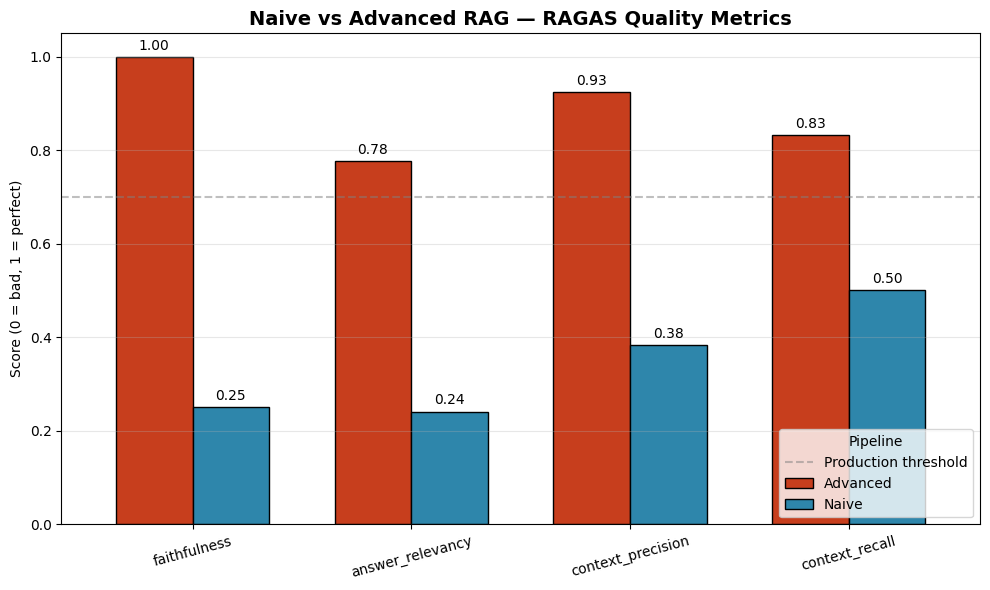

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
summary.T.plot(kind="bar", ax=ax, rot=15,
               color=["#C73E1D", "#2E86AB"],
               edgecolor="black", width=0.7)
ax.set_title("Naive vs Advanced RAG — RAGAS Quality Metrics", fontsize=14, fontweight="bold")
ax.set_ylabel("Score (0 = bad, 1 = perfect)")
ax.set_ylim(0, 1.05)
ax.axhline(y=0.7, color="gray", linestyle="--", alpha=0.5, label="Production threshold")
ax.legend(title="Pipeline", loc="lower right")
ax.grid(axis="y", alpha=0.3)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", padding=3, fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
print("Columns in df_all:")
print(df_all.columns.tolist())
print("\nFirst row preview:")
df_all.head(2)

Columns in df_all:
['pipeline', 'user_input', 'retrieved_contexts', 'response', 'reference', 'faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']

First row preview:


,pipeline,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,context_precision,context_recall
0,Naive,What is the main idea of this paper?,"[The\nLaw\nwill\nnever\nbe\nperfect\n,\nbut\ni...",Not found in document.,"The paper proposes the Transformer, a new netw...",0.0,0.0000,0.200000,0.5
1,Naive,What is the Transformer architecture?,[Figure 1: The Transformer - model architectur...,The Transformer architecture follows the overa...,The Transformer follows an encoder-decoder str...,1.0,0.9637,0.833333,1.0


In [ ]:
# Auto-detect the correct column names (RAGAS version compatibility)
question_col = next(
    (c for c in ["question", "user_input"] if c in df_all.columns),
    df_all.columns[1],  # fallback
)
print(f"Using question column: {question_col!r}")

# Filter to only metric columns that actually exist
available_metrics = [m for m in metric_cols if m in df_all.columns]
print(f"Available metrics: {available_metrics}")

# Pivot
comparison = df_all.pivot_table(
    index=question_col,
    columns="pipeline",
    values=available_metrics,
).round(2)

print("\n📋 PER-QUESTION SCORE COMPARISON")
comparison

Using question column: 'user_input'
Available metrics: ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']

📋 PER-QUESTION SCORE COMPARISON


answer_relevancy        \
pipeline                                            Advanced Naive   
user_input                                                           
What datasets were used in the experiments?              NaN  0.00   
What is the Transformer architecture?                   0.96  0.96   
What is the main idea of this paper?                    0.60  0.00   
Who are the authors of this paper?                       NaN  0.00   

                                            context_precision        \
pipeline                                             Advanced Naive   
user_input                                                            
What datasets were used in the experiments?               1.0  0.50   
What is the Transformer architecture?                     0.7  0.83   
What is the main idea of this paper?                      1.0  0.20   
Who are the authors of this paper?                        1.0  0.00   

                                            context_recall       faithfulness  \
pipeline                                          Advanced Naive     Advanced   
user_input                                                                      
What datasets were used in the experiments?            1.0   NaN          1.0   
What is the Transformer architecture?                  1.0   1.0          NaN   
What is the main idea of this paper?                   0.5   0.5          NaN   
Who are the authors of this paper?                     NaN   0.0          NaN   

                                                   
pipeline                                    Naive  
user_input                                         
What datasets were used in the experiments?   0.0  
What is the Transformer architecture?         1.0  
What is the main idea of this paper?          0.0  
Who are the authors of this paper?            0.0

In [ ]:
print("\n📋 ALL SCORES (Naive on top, Advanced below)")
df_all.sort_values("pipeline")[
    ["pipeline"] + [c for c in df_all.columns if c not in ["pipeline"]]
]


📋 ALL SCORES (Naive on top, Advanced below)


,pipeline,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,context_precision,context_recall
4,Advanced,What is the main idea of this paper?,"[Provided proper attribution is provided, Goog...",The main idea of this paper is to propose a ne...,"The paper proposes the Transformer, a new netw...",NaN,0.596503,1.000000,0.5
5,Advanced,What is the Transformer architecture?,[Figure 1: The Transformer - model architectur...,The Transformer architecture follows an overal...,The Transformer follows an encoder-decoder str...,NaN,0.955628,0.700000,1.0
6,Advanced,What datasets were used in the experiments?,[and semantic structure of the sentences.\n5\n...,The datasets used in the experiments are:\n\n1...,WMT 2014 English-German (about 4.5M sentence p...,1.0,NaN,1.000000,1.0
7,Advanced,Who are the authors of this paper?,"[Provided proper attribution is provided, Goog...",The authors of this paper are:\n\n1. Ashish Va...,"Ashish Vaswani, Noam Shazeer, Niki Parmar, Jak...",NaN,NaN,1.000000,NaN
0,Naive,What is the main idea of this paper?,"[The\nLaw\nwill\nnever\nbe\nperfect\n,\nbut\ni...",Not found in document.,"The paper proposes the Transformer, a new netw...",0.0,0.000000,0.200000,0.5
1,Naive,What is the Transformer architecture?,[Figure 1: The Transformer - model architectur...,The Transformer architecture follows the overa...,The Transformer follows an encoder-decoder str...,1.0,0.963700,0.833333,1.0
2,Naive,What datasets were used in the experiments?,[Table 3: Variations on the Transformer archit...,Not found in document.,WMT 2014 English-German (about 4.5M sentence p...,0.0,0.000000,0.500000,NaN
3,Naive,Who are the authors of this paper?,"[comments, corrections and inspiration.\nRefer...",Not found in document.,"Ashish Vaswani, Noam Shazeer, Niki Parmar, Jak...",0.0,0.000000,0.000000,0.0


---
## 🎓 Recap

| Pipeline | Retrieval | Reranking | Typical RAGAS lift |
|----------|-----------|-----------|---------------------|
| **Naive RAG** | FAISS only | none | baseline |
| **Advanced RAG** | FAISS + BM25 + RRF | Cross-Encoder | **+50–150%** on faithfulness & precision |

## 🛟 Troubleshooting

| Symptom | Fix |
|---|---|
| `ModuleNotFoundError: google.colab` | You're not on Colab — the portable loader handles this; ignore. |
| `ModuleNotFoundError: langchain.text_splitter` | Use `from langchain_text_splitters import ...` (already done). |
| `RateLimitError 429 ... TPD` | Free Groq daily cap. Wait ~15 min OR change judge model to `llama-3.1-8b-instant`. |
| First run is slow | First-time HF model download (~90 MB) + FAISS index build. Subsequent runs are fast. |
| `GROQ_API_KEY` not found | Set it via your platform's method (see prerequisites above). |

## 📖 Further reading
- [RAGAS docs](https://docs.ragas.io)
- [LangChain RAG guide](https://python.langchain.com/docs/tutorials/rag/)
- [Reciprocal Rank Fusion paper](https://plg.uwaterloo.ca/~gvcormac/cormacksigir09-rrf.pdf)
- ["Attention Is All You Need" (the demo PDF)](https://arxiv.org/abs/1706.03762)
